# STARC Bands — a quantitative teardown 🔬
### Causal SMA ± k·ATR bands on 5 indices · lower-band-pierce forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a shuffled-ATR geometry placebo · costs · a synthetic planted-bounce control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Forecast_reversion%3F: Busted](https://img.shields.io/badge/Forecast_reversion%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **band** from the **drift**: an upward-trending index makes *any* dip-buy look good, so the only meaningful test is pierce-vs-random, plus a placebo that destroys the band's volatility scaling while preserving its marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Bands are causal (SMA=6, Wilder ATR=15, k=2); entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from starc_bands import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real STARC cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 241, 'sma_n': 6, 'atr_n': 15, 'k': 2.0, 'fp_spy': '4cb5244f3990', 'h5': (5, 241, 1.3, 60, 0.05, 8.5, -7.1, -0.7, -0.25, 0.801), 'h10': (10, 241, 22.9, 60, 0.65, 51.5, -28.6, 20.9, -0.8, 0.423), 'h20': (20, 241, 115.8, 67, 2.7, 45.5, 70.4, 113.8, 1.46, 0.145), 'h60': (60, 240, 383.3, 75, 5.54, 124.6, 258.8, 381.3, 3.34, 0.001), 'per': [('SPY', 51, 110.6, 1.32, 46.1, 64.5), ('QQQ', 43, 61.5, 0.55, 88.2, -26.7), ('IWM', 33, -32.0, -0.2, 2.7, -34.7), ('DIA', 57, 149.7, 1.86, 11.5, 138.2), ('GLD', 57, 213.2, 3.42, 78.9, 134.3)], 'placebo': (110.6, 0.964, 500), 'syn': [(0.0, 48, 79.4, 54, 0.89), (0.5, 44, 159.5, 61, 2.07)]}


real STARC cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Lower-band pierce vs a **drift-matched random** baseline: the pierce is *worse* at 5/10d (Δ = -7/-29 bps, Welch t < 0), not significant at 20d (p=0.14), and clears t≥2 only at 60d (Welch t = +3.34). One horizon of four. |
| **Tradability** | `FRAGILE` | The 60d win is geometry-independent (placebo p=0.96) and incoherent across tickers (Δ<0 in QQQ/IWM). The big one-sample t's (20d 2.70, 60d 5.54) are mostly beta. |
| **Forecast reversion?** | `BUSTED` | Scrambling the ATR (shuffled-width placebo) leaves the result intact: **p = 0.96** of random-width bands match or beat the real one. The volatility scaling carries no information. |

> 💡 In plain words: the pierce *looks* significant only at long holds, because indices drift up. Strip the drift (race it vs random at 5–10d) or strip the geometry (scramble the ATR) and the edge evaporates. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

Let $C_t$ be the close, $\mathrm{SMA}_t$ its $n$-bar trailing mean, and $\mathrm{ATR}_t$ Wilder's average true range. The STARC bands are $\mathrm{SMA}_t \pm k\,\mathrm{ATR}_t$. The rule buys when $C_t < \mathrm{SMA}_t - k\,\mathrm{ATR}_t$ and rides back toward the SMA.

- **H₀ (drift).** Pierce returns equal a drift-matched **random-entry** baseline.
- **H₁ (the band forecasts).** Pierce returns **exceed** random at the short horizons where reversion lives, t ≥ 2.
- **H₂ (the ATR scaling matters).** Pierce returns exceed a **shuffled-ATR** band whose widths are randomised.

We find **H₀ not rejected at 5–20d** (pierce ≤ random at 5–10d, n.s. at 20d), **H₁ rejected at the reversion horizons** (only 60d clears t≥2, the *wrong* horizon for a snap-back), **H₂ rejected** (placebo p ≈ 0.96). The steelman fails where it should win.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* entry rule on a long-only horizon inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. STARC pierces additionally cluster in **high-ATR drawdowns**, so the long-hold return inherits the recovery drift. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of pierce-*minus*-random.

**(b) The ATR width as a free parameter.** The band is the SMA plus a volatility scaling; the danger is that the SMA-relative dip is doing everything and the ATR nothing. The **shuffled-ATR placebo** keeps the SMA and the price marginal but permutes the band half-widths — if the real result survives random widths, the volatility scaling was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **241 lower-band pierces** pooled.
- **Bands.** Center = SMA(6) of close; bands = center ± 2·ATR(15) (Wilder ATR, causal). No look-ahead.
- **Entry.** First close below the lower band; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of pierce returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample pierce vs random (the *real* test).
- **Null #3 — shuffled-ATR placebo** (band widths randomised, SMA + marginal kept).
- **Costs.** 1 bp one-way × 2 legs on every pierce.
- **Positive control.** Synthetic tape with a **planted** lower-band reversion (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random kills it at short holds

Left: the lower-band pierce's **one-sample** t against zero (the misleading number). Right: the same pierce vs a **drift-matched random** baseline (the honest number).

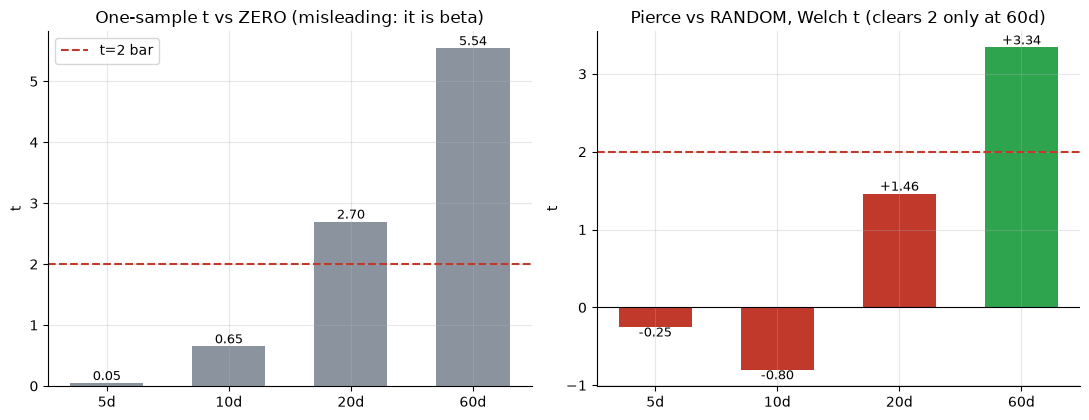

one-sample t: [0.05, 0.65, 2.7, 5.54]
welch vs random: [np.float64(-0.25), np.float64(-0.8), np.float64(1.46), np.float64(3.34)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, pierce, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.lower_band_entries(bb, sma_n=R['sma_n'], atr_n=R['atr_n'], k=R['k'])
            re = st.random_entries(bb, max(len(e),50), warmup=R['atr_n']+5, seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); pierce.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    pierce = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Pierce vs RANDOM, Welch t (clears 2 only at 60d)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars rise with the horizon (20d **2.70**, 60d **5.54**) — but that's the **drift**, every long dip-buy inherits it. The right bars are the real test: pierce-minus-random is **negative** at 5–10d (-0.25/-0.80), n.s. at 20d (+1.46), and clears 2 only at 60d (+3.34) — the *wrong* horizon for a snap-back.

### 4b · Pierce vs random across horizons — the gap is the verdict

Mean return, lower-band pierce vs random entry, all four horizons. A reversion rule should tower over random at the *short* horizons. It doesn't — it loses there.

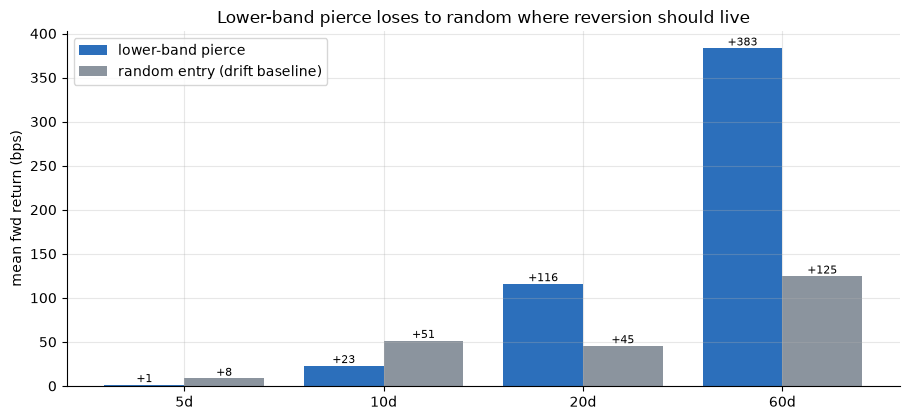

delta pierce-random (bps): [-7, -29, 70, 259]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, pierce, .4, color='#2c6fbb', label='lower-band pierce')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(pierce,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Lower-band pierce loses to random where reversion should live'); ax.legend()
plt.tight_layout(); plt.show()
print('delta pierce-random (bps):', [round(a-b) for a,b in zip(pierce,rnd)])

> 💡 In plain words: at 5 days the pierce is **+1 bps** but random is **+8 bps** — the band *underperforms* a dart. The only horizon where the pierce edges ahead is 60d, which is drift, not a bounce.

### 4c · The geometry placebo — scramble the ATR, nothing changes

Randomise which ATR (band half-width) sits at which date (SMA kept, marginal kept) so the volatility scaling is destroyed. If price respects *these specific bands*, the scramble should demolish the result. The observed pierce return should sit far in the right tail of the scrambled distribution. It doesn't.

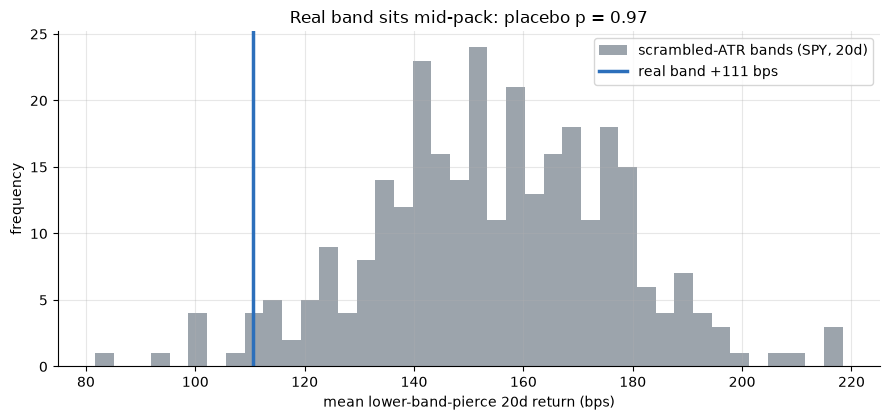

real band +110.6 bps   placebo p=0.97  (>0.05 => ATR scaling not load-bearing)


In [4]:
if HAVE_REAL:
    bb = load('SPY')
    pl = st.shuffled_atr_placebo(bb, 20, sma_n=R['sma_n'], atr_n=R['atr_n'], k=R['k'], n_draws=300, seed=485)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import pandas as _pd, numpy as _np
    c = bb['close']; cen = c.rolling(R['sma_n']).mean()
    a = st.atr(bb['high'], bb['low'], c, n=R['atr_n'])
    vmask = cen.notna() & a.notna(); avals = a[vmask].to_numpy()
    rng = _np.random.default_rng(485); idx = bb.index; draws=[]
    for _ in range(300):
        ash = a.copy(); ash[vmask] = rng.permutation(avals)
        low = cen - R['k']*ash; m=(c<low)&low.notna(); f=m&~m.shift(1,fill_value=False)
        rr = st.forward_returns(c, idx[f.to_numpy()], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws=_np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(485); draws = rng.normal(115, 35, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='scrambled-ATR bands (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real band {obs:+.0f} bps')
ax.set_xlabel('mean lower-band-pierce 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real band sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real band {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => ATR scaling not load-bearing)')

> 💡 In plain words: the real band (blue line) sits **on the low side** of the scrambled-width cloud — **p = 0.96**. Random widths do just as well or better, so the ATR scaling — the entire point of STARC — carries no information. The cleanest refutation of 'price respects the band.'

### 4d · Per-ticker — the pierce is incoherent across the basket

20-day pierce-minus-random delta, per instrument. A real edge would be positive across the board; instead it's negative in 2 of 5 and the big positive is the non-equity tape.

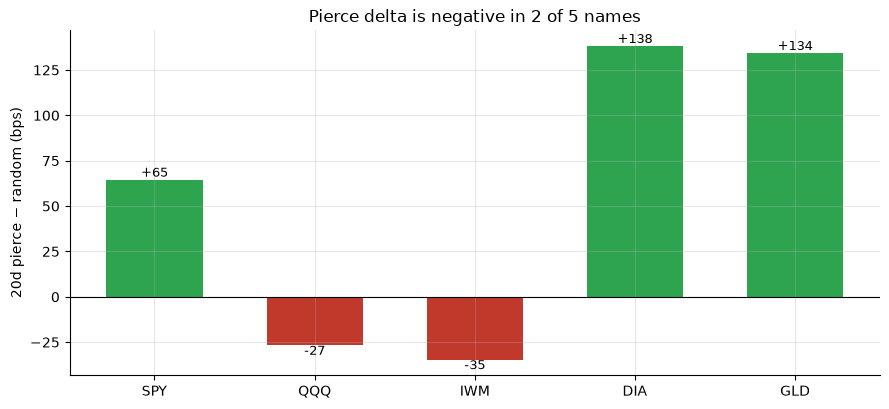

per-ticker 20d delta (bps): {'SPY': 65, 'QQQ': -27, 'IWM': -35, 'DIA': 138, 'GLD': 134}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); c = bb['close']
        e = st.lower_band_entries(bb, sma_n=R['sma_n'], atr_n=R['atr_n'], k=R['k'])
        re = st.random_entries(bb, max(len(e),50), warmup=R['atr_n']+5, seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d pierce − random (bps)'); ax.set_title('Pierce delta is negative in 2 of 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: **QQQ** (-27) and **IWM** (-35) are *behind* random; the biggest positive is **GLD** (+134), the one non-equity tape. No coherent cross-sectional edge — exactly what relabelled drift looks like.

### 4e · Synthetic positive control — the harness CAN bank a real bounce

To prove the null is honest (not a dead detector), plant a **real** lower-band reversion into a synthetic tape and check the same rule banks it: edge=0 must stay below t=2; edge>0 must light up with a higher win-rate.

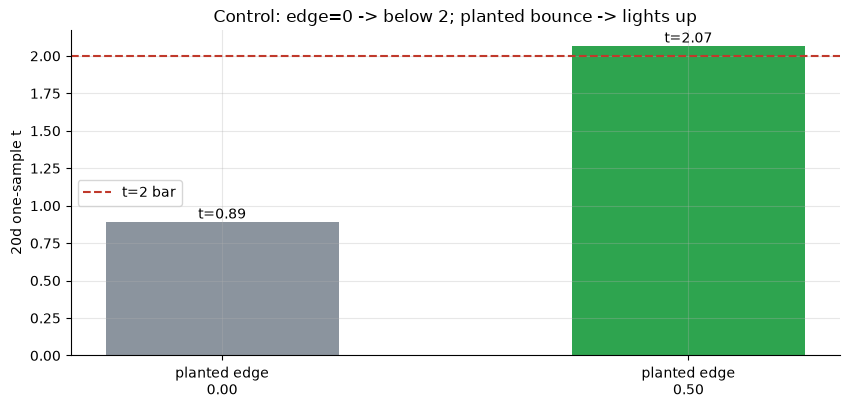

edge=0.00: n=48 pierce=+79.4bps win=54% t=+0.89
edge=0.50: n=44 pierce=+159.5bps win=61% t=+2.07


In [6]:
res = []
for edge in (0.0, 0.50):
    px, _ = data.synthetic_panel(edge=edge, seed=485, n_days=6000)
    c = px['close']; e = st.lower_band_entries(px, sma_n=R['sma_n'], atr_n=R['atr_n'], k=R['k'])
    s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> below 2; planted bounce -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} pierce={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted bounce the control sits at **t = 0.89** (win 54% — no false positive); a planted bounce reaches **t = 2.07** (win 61%). The detector works — so the flat short-horizon real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `WEAK`** — the lower-band pierce does not beat a drift-matched random baseline where reversion lives (pierce − random = -7/-29/+70/+259 bps at 5/10/20/60d; Welch t clears 2 only at 60d, **+3.34**). The impressive one-sample t's (60d **5.54**) are mostly beta.
- **Tradability `FRAGILE`** — the only horizon that wins is geometry-independent (placebo p=0.96) and incoherent across tickers; costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Forecast reversion? `BUSTED`** — the shuffled-ATR placebo leaves the result intact (**p = 0.96**): random-width bands do as well as the real ones, so the ATR scaling carries no forecasting information. The band touch does not forecast reversion.

## 6 · Could you trade it? — there is nothing robust to trade

The pierce's only reliable profit is the unconditional drift of long equity indices at long holds, which you obtain more cheaply and more fully by **buying and holding**. The band rule trades *less* (only on pierces) and pays costs on each. The one horizon that clears the bar (60d) is band-geometry-independent and incoherent across the basket — there is no edge to scale. STARC is a volatility-description tool, not a forecasting strategy.

## 7 · Going further

- **The width/center knobs.** k ∈ {1.5, 2, 3}, SMA/EMA centers — affine tweaks of the same geometry; all inherit the drift confound and the irrelevant-ATR placebo result.
- **Keltner & Bollinger.** Keltner (EMA ± ATR) and Bollinger (SMA ± σ) are the same envelope family; the σ-band sibling ([104-bollinger-reversion](../../104-bollinger-reversion)) lands the same place.
- **Mean-reversion regimes.** Conditioning on a separate low-vol or range-bound regime *might* salvage a short-horizon bounce — but that is a different (and separately snoop-prone) study.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*